# 🌍 Analyse du Changement Climatique en Afrique (1980-2023)

**Pays analysés :** Tunisie, Cameroun, Sénégal, Égypte, Angola

**Objectif :** Visualiser l'évolution des températures et identifier les tendances du réchauffement climatique.

## 📦 1. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Configuration style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print('✅ Bibliothèques importées avec succès')

✅ Bibliothèques importées avec succès


## 📊 2. Chargement et exploration des données

In [2]:
# Chargement du dataset
df = pd.read_csv('Africa_climate_change.csv')

print(f'📋 Dimensions du dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'\n📅 Période : {df["DATE"].min()} → {df["DATE"].max()}')
print(f'\n🌍 Pays : {df["COUNTRY"].nunique()} pays uniques')
df.head(10)

📋 Dimensions du dataset : 464,815 lignes × 6 colonnes

📅 Période : 19800101 000000 → 20230823 000000

🌍 Pays : 5 pays uniques


,DATE,PRCP,TAVG,TMAX,TMIN,COUNTRY
0,19800101 000000,NaN,54.0,61.0,43.0,Tunisia
1,19800101 000000,NaN,49.0,55.0,41.0,Tunisia
2,19800101 000000,0.0,72.0,86.0,59.0,Cameroon
3,19800101 000000,NaN,50.0,55.0,43.0,Tunisia
4,19800101 000000,NaN,75.0,91.0,NaN,Cameroon
5,19800101 000000,NaN,52.0,61.0,45.0,Tunisia
6,19800101 000000,0.0,76.0,97.0,59.0,Senegal
7,19800101 000000,0.0,74.0,95.0,59.0,Senegal
8,19800101 000000,0.0,78.0,93.0,63.0,Senegal
9,19800101 000000,0.0,76.0,91.0,59.0,Senegal


In [3]:
# Informations sur le dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464815 entries, 0 to 464814
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   DATE     464815 non-null  object 
 1   PRCP     177575 non-null  float64
 2   TAVG     458439 non-null  float64
 3   TMAX     363901 non-null  float64
 4   TMIN     332757 non-null  float64
 5   COUNTRY  464815 non-null  object 
dtypes: float64(4), object(2)
memory usage: 21.3+ MB


In [4]:
# Statistiques descriptives
df.describe()

,PRCP,TAVG,TMAX,TMIN
count,177575.000000,458439.000000,363901.000000,332757.000000
mean,0.120941,77.029838,88.713969,65.548262
std,0.486208,11.523634,13.042631,11.536547
min,0.000000,-49.000000,41.000000,12.000000
25%,0.000000,70.000000,81.000000,58.000000
50%,0.000000,80.000000,90.000000,68.000000
75%,0.010000,85.000000,99.000000,74.000000
max,19.690000,110.000000,123.000000,97.000000


In [5]:
# Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Manquantes': missing, 'Pourcentage': missing_pct})
missing_df = missing_df[missing_df['Manquantes'] > 0].sort_values('Manquantes', ascending=False)
print('🔍 Valeurs manquantes :')
missing_df

🔍 Valeurs manquantes :


,Manquantes,Pourcentage
PRCP,287240,61.796629
TMIN,132058,28.410873
TMAX,100914,21.710573
TAVG,6376,1.371729


## 🧹 3. Nettoyage et préparation des données

In [6]:
# Conversion de la date
df['DATE'] = pd.to_datetime(df['DATE'].astype(str).str[:8], format='%Y%m%d', errors='coerce')

# Extraction année, mois, jour
df['YEAR'] = df['DATE'].dt.year
df['MONTH'] = df['DATE'].dt.month
df['DAY'] = df['DATE'].dt.day

# Période (avant/après 2000)
df['PERIODE'] = df['YEAR'].apply(lambda x: 'Avant 2000' if x < 2000 else 'Après 2000')

print('✅ Données nettoyées')
df.head()

✅ Données nettoyées


,DATE,PRCP,TAVG,TMAX,TMIN,COUNTRY,YEAR,MONTH,DAY,PERIODE
0,1980-01-01,NaN,54.0,61.0,43.0,Tunisia,1980,1,1,Avant 2000
1,1980-01-01,NaN,49.0,55.0,41.0,Tunisia,1980,1,1,Avant 2000
2,1980-01-01,0.0,72.0,86.0,59.0,Cameroon,1980,1,1,Avant 2000
3,1980-01-01,NaN,50.0,55.0,43.0,Tunisia,1980,1,1,Avant 2000
4,1980-01-01,NaN,75.0,91.0,NaN,Cameroon,1980,1,1,Avant 2000


In [7]:
# Distribution des données par pays
print('🌍 Répartition par pays :')
df['COUNTRY'].value_counts()

🌍 Répartition par pays :


COUNTRY
Senegal     183262
Egypt       149191
Tunisia      79301
Cameroon     41554
Angola       11507
Name: count, dtype: int64

## 📈 4. Visualisations - Températures moyennes par pays

In [8]:
# Température moyenne par pays et par année
temp_by_country_year = df.groupby(['COUNTRY', 'YEAR'])[['TMAX', 'TMIN', 'TAVG']].mean().reset_index()

# Graphique interactif Plotly
fig = px.line(temp_by_country_year, x='YEAR', y='TAVG', color='COUNTRY',
              title='🌡️ Évolution de la Température Moyenne par Pays (1980-2023)',
              labels={'TAVG': 'Température Moyenne (°F)', 'YEAR': 'Année'},
              height=600)
fig.update_layout(hovermode='x unified')
fig.show()

In [9]:
# Température MAX et MIN par pays
fig = make_subplots(rows=1, cols=2, subplot_titles=('Température MAX', 'Température MIN'))

for country in df['COUNTRY'].unique():
    data = temp_by_country_year[temp_by_country_year['COUNTRY'] == country]
    fig.add_trace(go.Scatter(x=data['YEAR'], y=data['TMAX'], name=country, mode='lines'), row=1, col=1)
    fig.add_trace(go.Scatter(x=data['YEAR'], y=data['TMIN'], name=country, mode='lines', showlegend=False), row=1, col=2)

fig.update_layout(title_text='🌡️ Températures Maximales et Minimales (1980-2023)', height=500)
fig.show()

## 📊 5. Comparaison avant/après 2000

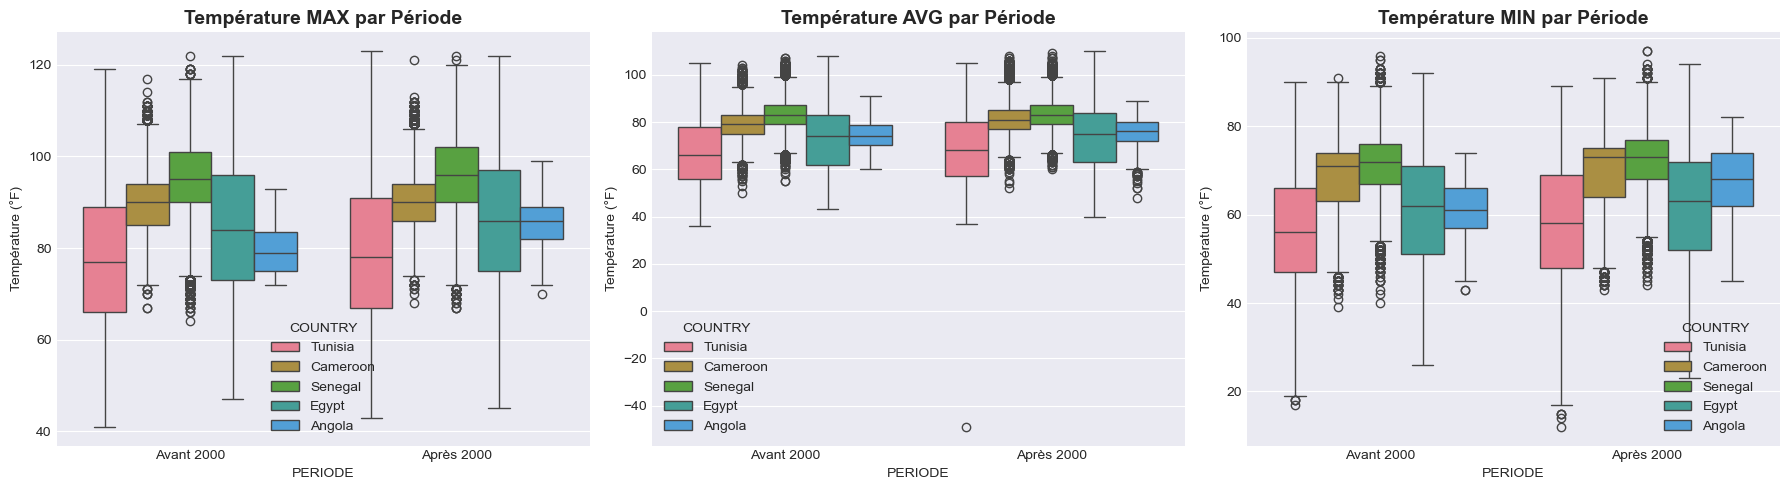

In [10]:
# Box plot par période
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='PERIODE', y='TMAX', hue='COUNTRY', ax=axes[0])
axes[0].set_title('Température MAX par Période', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Température (°F)')

sns.boxplot(data=df, x='PERIODE', y='TAVG', hue='COUNTRY', ax=axes[1])
axes[1].set_title('Température AVG par Période', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Température (°F)')

sns.boxplot(data=df, x='PERIODE', y='TMIN', hue='COUNTRY', ax=axes[2])
axes[2].set_title('Température MIN par Période', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Température (°F)')

plt.tight_layout()
plt.savefig('comparison_before_after_2000.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Calcul de l'augmentation moyenne par pays
before_2000 = df[df['YEAR'] < 2000].groupby('COUNTRY')['TAVG'].mean()
after_2000 = df[df['YEAR'] >= 2000].groupby('COUNTRY')['TAVG'].mean()
increase = after_2000 - before_2000

increase_df = pd.DataFrame({
    'Pays': increase.index,
    'Avant 2000 (°F)': before_2000.values,
    'Après 2000 (°F)': after_2000.values,
    'Augmentation (°F)': increase.values
})

print('🔥 Augmentation de la température moyenne par pays :')
increase_df.sort_values('Augmentation (°F)', ascending=False)

🔥 Augmentation de la température moyenne par pays :


,Pays,Avant 2000 (°F),Après 2000 (°F),Augmentation (°F)
1,Cameroon,78.851086,81.482061,2.630975
4,Tunisia,66.806525,68.517471,1.710946
0,Angola,74.256757,75.943456,1.686699
2,Egypt,73.160134,74.222831,1.062697
3,Senegal,82.724144,83.172957,0.448813


## 🔥 6. Analyse du réchauffement climatique

In [12]:
# Tendance globale par décennie
df['DECADE'] = (df['YEAR'] // 10) * 10
temp_by_decade = df.groupby(['DECADE', 'COUNTRY'])['TAVG'].mean().reset_index()

fig = px.bar(temp_by_decade, x='DECADE', y='TAVG', color='COUNTRY', barmode='group',
             title='📊 Température Moyenne par Décennie et par Pays',
             labels={'TAVG': 'Température Moyenne (°F)', 'DECADE': 'Décennie'},
             height=600)
fig.show()

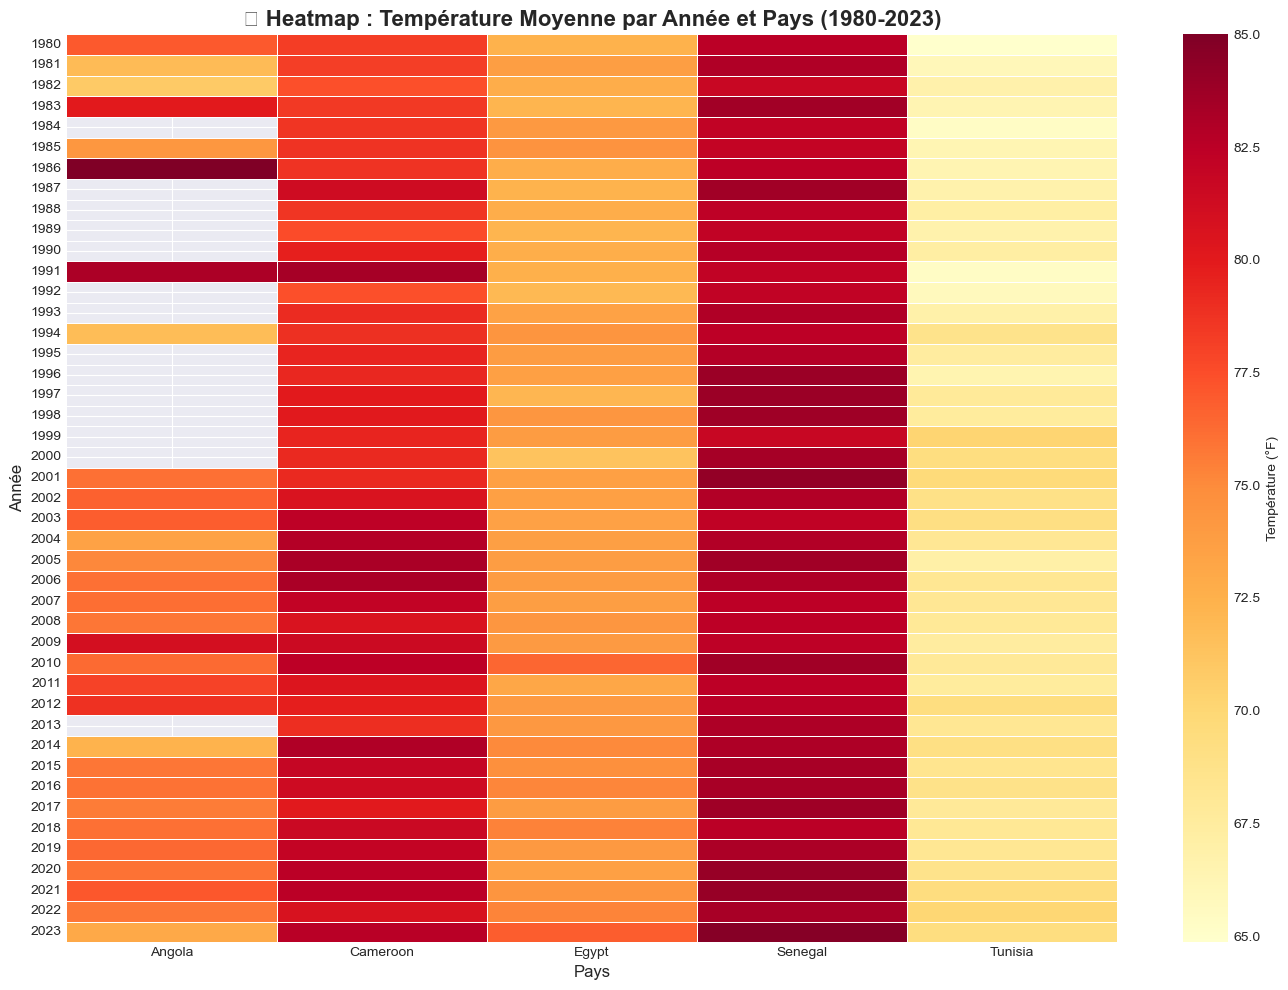

In [13]:
# Heatmap : Température moyenne par année et par pays
pivot = df.groupby(['YEAR', 'COUNTRY'])['TAVG'].mean().reset_index().pivot(index='YEAR', columns='COUNTRY', values='TAVG')

plt.figure(figsize=(14, 10))
sns.heatmap(pivot, cmap='YlOrRd', cbar_kws={'label': 'Température (°F)'}, linewidths=0.5)
plt.title('🔥 Heatmap : Température Moyenne par Année et Pays (1980-2023)', fontsize=16, fontweight='bold')
plt.xlabel('Pays', fontsize=12)
plt.ylabel('Année', fontsize=12)
plt.tight_layout()
plt.savefig('heatmap_temperature.png', dpi=300, bbox_inches='tight')
plt.show()

## 📉 7. Distribution des températures

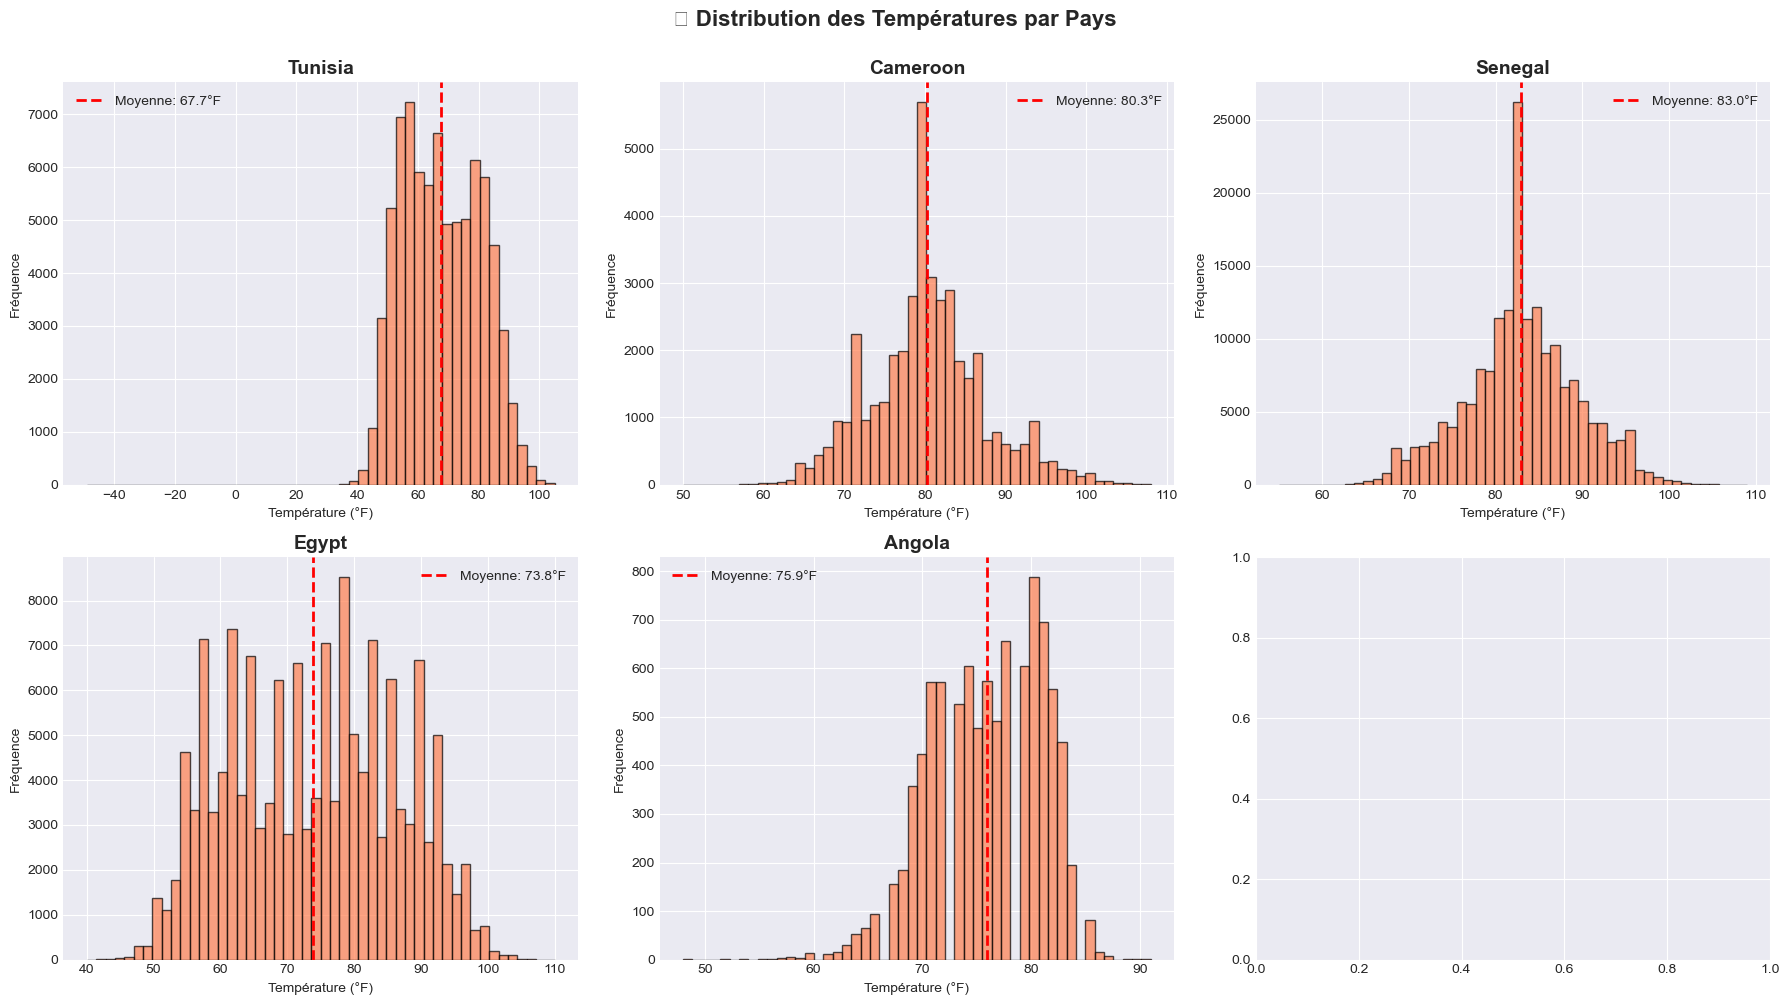

In [14]:
# Histogrammes par pays
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, country in enumerate(df['COUNTRY'].unique()):
    if idx < len(axes):
        data = df[df['COUNTRY'] == country]['TAVG'].dropna()
        axes[idx].hist(data, bins=50, color='coral', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{country}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Température (°F)')
        axes[idx].set_ylabel('Fréquence')
        axes[idx].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {data.mean():.1f}°F')
        axes[idx].legend()

plt.suptitle('📊 Distribution des Températures par Pays', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('distribution_temperatures.png', dpi=300, bbox_inches='tight')
plt.show()

## 🎯 8. Conclusions et insights

In [15]:
print('🎯 CONCLUSIONS PRINCIPALES :')
print('=' * 80)
print(f'\n1️⃣ Augmentation globale de la température entre avant/après 2000 :')
print(increase_df.to_string(index=False))
print(f'\n2️⃣ Pays le plus touché : {increase_df.iloc[0]["Pays"]} (+{increase_df.iloc[0]["Augmentation (°F)"]:.2f}°F)')
print(f'\n3️⃣ Moyenne d"augmentation : +{increase_df["Augmentation (°F)"].mean():.2f}°F')
print(f'\n4️⃣ Période d"analyse : {df["YEAR"].min()} - {df["YEAR"].max()} ({df["YEAR"].max() - df["YEAR"].min()} ans)')
print(f'\n5️⃣ Volume de données : {len(df):,} observations quotidiennes')
print('\n✅ Le réchauffement climatique est VISIBLE dans tous les pays analysés.')

🎯 CONCLUSIONS PRINCIPALES :

1️⃣ Augmentation globale de la température entre avant/après 2000 :
    Pays  Avant 2000 (°F)  Après 2000 (°F)  Augmentation (°F)
  Angola        74.256757        75.943456           1.686699
Cameroon        78.851086        81.482061           2.630975
   Egypt        73.160134        74.222831           1.062697
 Senegal        82.724144        83.172957           0.448813
 Tunisia        66.806525        68.517471           1.710946

2️⃣ Pays le plus touché : Angola (+1.69°F)

3️⃣ Moyenne d"augmentation : +1.51°F

4️⃣ Période d"analyse : 1980 - 2023 (43 ans)

5️⃣ Volume de données : 464,815 observations quotidiennes

✅ Le réchauffement climatique est VISIBLE dans tous les pays analysés.


---

## 👨‍💻 Auteur

**Cheikh Niang** - Data Scientist Junior

📧 cheikhniang159@gmail.com  
🔗 [LinkedIn](https://www.linkedin.com/in/cheikh-niang-5370091b5/)  
💼 [Portfolio](https://github.com/chniang)

---